# How many customers does Kalpa have, and how many came back for a second order?

**Week 1, Monday, chapter 3 of 6.** Marketing's Rs 12 crore buys customers, and Meera wants to
know how many Kalpa already has and whether they come back.

**Who needs the answer.** Meera needs the customer count before she funds acquisition: if
Kalpa's customers never come back, acquisition is the only branch left, and if they do,
frequency, orders per customer, is a branch she can grow without buying anyone new. The
marketing lead and the head of Retail-Plus own those two branches. A count that reads "nobody
comes back" makes frequency look dead and hands the Rs 12 crore to acquisition on a counting
slip.

**The questions on the way.**

1. How do we count customers when a row is an order?
2. How many customers came back for a second order?
3. What goes wrong if every row is counted as a customer?
4. Does the mean of the per-customer counts give the same rate?
5. What changes when only delivered orders count?

The metric at stake is customers, and orders per customer: orders over distinct customers in
the window. Reliance Retail reported 396 million registered customers at 30 June 2026 (Reliance
Industries media release, 17 July 2026), and a registered customer is a denominator of its own:
a quarter's orders divided by it give a different, smaller metric from orders per customer who
ordered. Section 5 of the retail dossier, `study-notes/C2_W01_D01_domain_retail_STUDENT.md`,
covers frequency and repeat rate.

Chapter 2 measured the first branch: booked revenue of Rs 5,44,810 over 30 orders is an AOV of
Rs 18,160. Chapter 1 had already set the readings beside it, with 21 of the 30 orders delivered
and staying delivered. This chapter fills the two customer branches and checks that the tree
multiplies back.

> **Kavya's review.** One person can leave several rows, so count people by their id and say in
> the note how you counted them.

**Setup.** The first cell finds the shared helper, loads the 30 orders from `../data/`, applies
chapter 1's `int()` fix to every amount, and sums booked revenue.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

ORDERS = kit.load_records()

for order in ORDERS:
    order["amount"] = int(order["amount"])     # chapter 1's fix for an amount stored as text
revenue = sum(order["amount"] for order in ORDERS)
print(len(ORDERS), "orders,", kit.rupees(revenue), "booked")

30 orders, Rs 5,44,810 booked


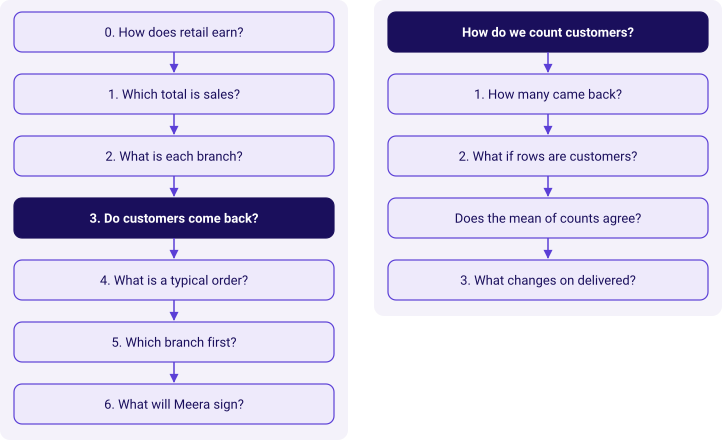

In [2]:
kit.side_by_side(
    kit.vflow(['0. How does retail earn?', '1. Which total is sales?', '2. What is each branch?', '3. Do customers come back?', '4. What is a typical order?', '5. Which branch first?', '6. What will Meera sign?'], lit=3, show=False),
    kit.vflow(['How do we count customers?', '1. How many came back?', '2. What if rows are customers?', 'Does the mean of counts agree?', '3. What changes on delivered?'], lit=0, show=False),
)

## How do we count customers when a row is an order?

A row in the file is one order, and one customer can place several, so there are four ways to
count customers, sized here on the 30 rows.

| Option | Passes over the rows | What it answers | Error on this file |
|---|---|---|---|
| A. `len(ORDERS)`, the row count | none | how many orders | It counts a repeat customer once per order. |
| B. `len(set(ids))`, distinct ids | one | how many customers | None, though it says nothing about who came back. |
| C. A dictionary of orders per id | one | how many customers, how many orders each, who came back | None. |
| D. Sort the ids and count where they change | a sort and a pass | how many customers | None if done right, and it is easy to miscount by hand. |

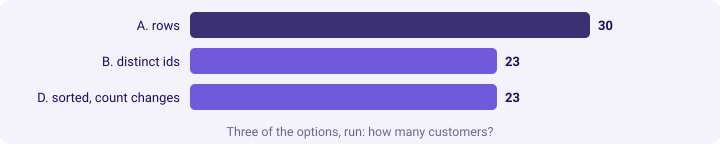

In [3]:
ids = [order["customer_id"] for order in ORDERS]
options = [("A. rows", len(ORDERS)), ("B. distinct ids", len(set(ids))),
           ("D. sorted, count changes", 1 + sum(1 for a, b in zip(sorted(ids), sorted(ids)[1:]) if a != b))]
kit.bars(options, lit=(0,), title="Three of the options, run: how many customers?")
kit.check("options B and D agree on distinct customers", options[1][1] == options[2][1], options[1][1])
kit.check("option A counts more customers than there are people", options[0][1] > options[1][1])

**The best-fit call.** C: one pass fills both customer branches and names the repeat buyers,
which is the number Meera's question turns on, and B and D agree with it on 23 customers where
A reads 30. B is the right call when only the count is needed. **What would change it:** at
millions of rows the same count is one `COUNT(DISTINCT customer_id)` in the warehouse, which
Week 2 teaches, and a loop in a notebook stops being the tool.

## 1. How many customers came back for a second order?

A set says how many customers there are and forgets the rest. A dictionary keeps a count per
id: the customer id is the key, and the count of that customer's orders is the value.

**Predict before you run.** Of the 23 customers, how many bought more than once?

- a) None, because orders per customer is close to 1.
- b) 7, the difference between 30 orders and 23 customers.
- c) 16, the customers who are not new.
- d) 23, because the rate is above 1.

23 customers, 1.30 orders each; 16 bought once, 7 came back


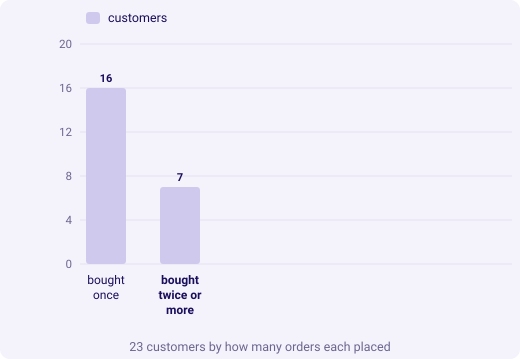

In [4]:
counts = {}
for order in ORDERS:
    cid = order["customer_id"]
    counts[cid] = counts.get(cid, 0) + 1
customers = len(counts)
per_customer = len(ORDERS) / customers
once = sum(1 for c in counts.values() if c == 1)
repeat = customers - once
print(f"{customers} customers, {per_customer:.2f} orders each; {once} bought once, {repeat} came back")
kit.columns(["bought once", "bought twice or more"], [("customers", [once, repeat])], lit=(1,),
            width=520, title="23 customers by how many orders each placed")

In [5]:
kit.check("orders per customer is 1.30 on distinct customers", round(per_customer, 2) == 1.30)
kit.check("16 bought once and 7 came back", (once, repeat) == (16, 7))
kit.check("the counts add back to 30 orders", sum(counts.values()) == 30)

**What happened.** The answer is b: 7 of the 23 customers came back for a second order, 16
bought once, and 30 orders over 23 customers is 1.30 orders each. The difference between orders
and customers equals the repeat buyers here because nobody bought three times; a third order
would part the two, which is why the dictionary is the count to trust. One repeat customer is
recorded as Retail-Core on one order and Retail-Plus on the other, since the segment is recorded
on each order, so a count of customers per segment has to say which order's segment it used.
With every branch measured, the tree multiplies back:

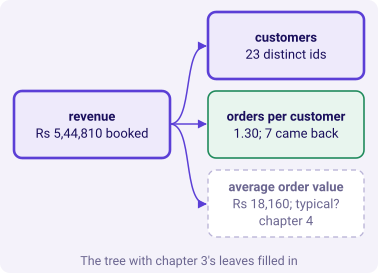

In [6]:
aov = revenue / len(ORDERS)
rebuilt = customers * per_customer * aov
kit.driver_tree({"label": "revenue", "note": kit.rupees(revenue) + " booked", "kind": "known", "children": [
    {"label": "customers", "note": f"{customers} distinct ids", "kind": "known"},
    {"label": "orders per customer", "note": f"{per_customer:.2f}; {repeat} came back", "kind": "good"},
    {"label": "average order value", "note": kit.rupees(aov) + "; typical? chapter 4", "kind": "unknown"}]},
    title="The tree with chapter 3's leaves filled in")
kit.check("customers x orders per customer x AOV = booked revenue", round(rebuilt) == revenue, kit.rupees(rebuilt))

## 2. What goes wrong if every row is counted as a customer?

The first draft a colleague sent Meera counted this leaf in one line, from the row count.

**Predict before you run.** The hurried cell divides orders by the number of rows. What
orders-per-customer figure does it report?

- a) 1.30, the figure the tree needs.
- b) 0.77, because customers outnumber orders.
- c) 1.00, one order for every customer.
- d) 23.00, because the division runs the wrong way.

**The plausible wrong answer.**

Customers: 30
Orders per customer: 1.00, so nobody comes back


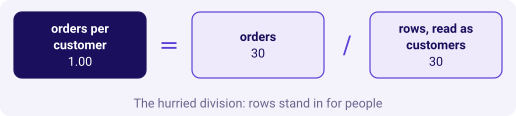

In [7]:
customers_hurried = len(ORDERS)
per_customer_hurried = len(ORDERS) / customers_hurried
print("Customers:", customers_hurried)
print(f"Orders per customer: {per_customer_hurried:.2f}, so nobody comes back")
kit.equation([f"orders per customer\n{per_customer_hurried:.2f}", "=", "orders\n30", "/",
              "rows, read as customers\n30"], title="The hurried division: rows stand in for people")

**Why it is wrong.** The division is correct and its denominator is wrong: a row is an order,
and one customer can place several. Reported to Meera, "1.00 orders per customer, nobody comes
back" says frequency is dead and the only way to grow is to buy customers, which is marketing's
case for Rs 12 crore made by a counting slip. The check compares the ids in the list with the
distinct ids.

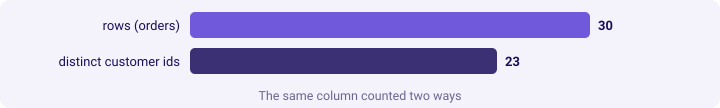

In [8]:
distinct = set(ids)
kit.bars([("rows (orders)", len(ids)), ("distinct customer ids", len(distinct))], lit=(1,),
         title="The same column counted two ways")
kit.check("the list holds one id per row", len(ids) == 30)
kit.check("the set holds 23 distinct customers", len(distinct) == 23, len(distinct))

**What happened.** The answer is c: counting rows as customers reports 30 customers at 1.00
orders each and says nobody comes back. The fix divides by distinct customers, as the build did:
30 / 23 = 1.30 orders each, the 7 who came back are visible again, and "nobody comes back" drops
out of the case for the Rs 12 crore.

## Does the mean of the per-customer counts give the same rate?

Orders per customer is also the mean of the dictionary's values: each customer's order count,
averaged over customers. It must equal orders over distinct customers.

In [9]:
second_route = sum(counts.values()) / len(counts)
kit.table(["route", "orders per customer"],
          [("len(ORDERS) / len(set(ids))", f"{len(ORDERS) / len(distinct):.4f}"),
           ("mean of the per-customer counts", f"{second_route:.4f}")],
          caption="Two routes to one rate")
kit.check("the two routes agree", abs(second_route - len(ORDERS) / len(distinct)) < 1e-12)
kit.check("the dictionary's keys are the set's members", set(counts) == distinct)

route,orders per customer
len(ORDERS) / len(set(ids)),1.3043
mean of the per-customer counts,1.3043


**What happened.** It does: both routes give 1.3043 orders per customer, 1.30 to two places.

**When to switch.** The ratio route needs only two counts, which is what a report holds; the
counts route needs the rows and also gives the spread, 16 customers at one order and 7 at two,
which the ratio hides. Use the counts whenever someone will ask how many came back.

> **Kavya's review.** Your first 30 was a count of rows, divided as if it were people. Every
> rate you send upstairs carries the name of its denominator, and a count of people comes from
> their ids.

## 3. What changes when only delivered orders count?

Anand's books keep what was delivered and stayed delivered, so the count he will check is the
one on the 21 delivered orders. The dictionary is rebuilt on those orders alone.

**Predict before you run.** On the 21 delivered orders, how many customers kept two delivered
orders?

- a) 7, the same as on booked orders.
- b) 2.
- c) None.
- d) 19.

delivered: 21 orders from 19 customers, 1.11 each; 2 kept two


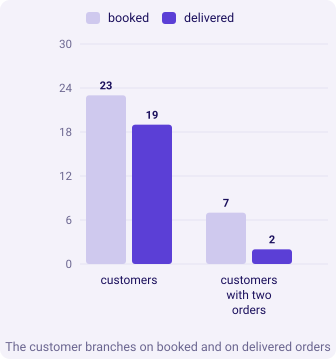

In [10]:
delivered = [o for o in ORDERS if o["status"] == "delivered"]
d_counts = {}
for order in delivered:
    d_counts[order["customer_id"]] = d_counts.get(order["customer_id"], 0) + 1
d_customers = len(d_counts)
d_per = len(delivered) / d_customers
d_repeat = sum(1 for c in d_counts.values() if c > 1)
print(f"delivered: {len(delivered)} orders from {d_customers} customers, {d_per:.2f} each; {d_repeat} kept two")
kit.columns(["customers", "customers with two orders"],
            [("booked", [customers, repeat]), ("delivered", [d_customers, d_repeat])],
            title="The customer branches on booked and on delivered orders")
kit.check("delivered orders come from 19 customers", d_customers == 19, d_customers)
kit.check("2 customers kept two delivered orders", d_repeat == 2)
kit.check("the delivered counts add back to the delivered orders", sum(d_counts.values()) == len(delivered))

**What happened.** The answer is b: on the 21 delivered orders, 19 customers kept 1.11 orders
each and only 2 kept two. Customers still come back on Anand's definition, and the drop from 7
to 2 says the repeat orders often did not stay sold, which the afternoon's cases take up.

### How would you answer an interviewer who asks how you count customers?

**[F] Your extract shows 30 orders and 30 customers; what do you check before saying nobody
comes back?** "Whether 30 customers means 30 distinct ids or 30 rows. I compare the length of
the id column with the length of its set; on Kalpa's quarter that is 30 against 23, so seven
orders came from people who had already bought. I would also check the window, since a customer
who buys every four months looks one-time in one quarter, and whether one person can carry two
ids."

**[SV] A list against a dictionary: when do you reach for each?** "A list when order matters or
I will walk every item. A dictionary when I look things up or count by a key, such as orders per
customer id. Real records are both: a list of dictionaries, one per row, which is what a JSON
array from an API looks like. Checking membership in a list walks every item, while a dictionary
goes straight to its key."

**[SV] How do you count distinct customers in Python, and why does a set give the answer a list
does not?** "`len(set(ids))`, because a set keeps each value once however often it is added,
while a list keeps every occurrence. When I also need orders per customer, a dictionary keyed by
id gives both."

### Which channel did the 7 repeat buyers come back through?

A set answers overlap questions: `&` keeps the ids two sets share and `|` the ids in either. A
frequency plan has to reach customers where they come back, so the cell asks which channels the
repeat buyers used. All 7 came back through a different channel from their first order; seven
customers are too few to call that a pattern, and it does say a frequency plan built on one
channel would miss how these customers return.

question,set expression,answer
customers on the app,len(app),10
customers on both app and web,len(app & web),3
customers on any channel,len(app | web | store),23
customers on more than one channel,counted,7


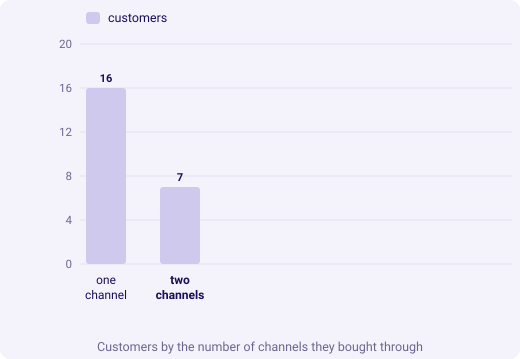

In [11]:
by_channel = {"app": set(), "web": set(), "store": set()}
for order in ORDERS:
    by_channel[order["channel"]].add(order["customer_id"])
multi = sum(1 for cid in counts if sum(cid in s for s in by_channel.values()) > 1)
kit.table(["question", "set expression", "answer"],
          [("customers on the app", "len(app)", len(by_channel["app"])),
           ("customers on both app and web", "len(app & web)", len(by_channel["app"] & by_channel["web"])),
           ("customers on any channel", "len(app | web | store)",
            len(by_channel["app"] | by_channel["web"] | by_channel["store"])),
           ("customers on more than one channel", "counted", multi)],
          caption="Set questions on the same 30 orders")
kit.columns(["one channel", "two channels"], [("customers", [len(counts) - multi, multi])], lit=(1,),
            width=520, title="Customers by the number of channels they bought through")
kit.check("the union of the channels is all 23 customers",
          len(by_channel["app"] | by_channel["web"] | by_channel["store"]) == 23)
kit.check("every repeat buyer used a second channel", multi == repeat == 7, multi)

### When does orders less customers stop counting the repeat buyers?

On Kalpa's file, 30 orders less 23 customers is 7, and 7 customers came back, because nobody
bought three times. On three **invented** customers with 3, 1 and 1 orders, orders less
customers is 2 while only 1 customer came back: the dictionary counts people, and the
subtraction counts extra orders.

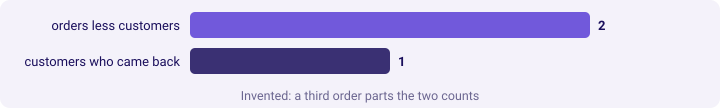

In [12]:
invented = {"X-1": 3, "X-2": 1, "X-3": 1}          # invented customers, for the mechanism only
extra_orders = sum(invented.values()) - len(invented)
came_back = sum(1 for n in invented.values() if n > 1)
kit.bars([("orders less customers", extra_orders), ("customers who came back", came_back)], lit=(1,),
         title="Invented: a third order parts the two counts")
kit.check("on the invented three the two counts differ", extra_orders != came_back)

## Is frequency a branch Meera can grow without buying anyone new?

It is. Kalpa's 30 orders came from 23 customers, and 7 of them came back for a second order in
the quarter, 1.30 orders each; on delivered orders the same count is 19 customers at 1.11 each,
2 of whom kept two.

- How do we count customers when a row is an order? We count distinct ids, with a dictionary
  that also counts each customer's orders.
- How many came back? 7 of the 23 came back, and 16 bought once.
- What goes wrong if every row is a customer? The draft reports 30 customers at 1.00 orders
  each and says nobody comes back.
- Does the mean of the counts agree? It does, at 1.30 by both routes.
- What changes on delivered orders? The count is 19 customers at 1.11 orders each, and 2 kept
  two.

In [13]:
kit.table(["What we now know", "The evidence"],
          [("A row is an order, and customers are counted by id", "30 rows, 23 customers"),
           ("Frequency is a live branch", "1.30 orders each; 7 of 23 came back"),
           ("The tree multiplies back", "23 x 1.30 x Rs 18,160 = Rs 5,44,810"),
           ("On delivered orders the branch thins", "19 customers, 1.11 each, 2 kept two")],
          caption="Chapter 3: do customers come back")
kit.check_summary()
print("Next: chapter 4 asks whether Rs 18,160 describes a typical Kalpa order.")

What we now know,The evidence
"A row is an order, and customers are counted by id","30 rows, 23 customers"
Frequency is a live branch,1.30 orders each; 7 of 23 came back
The tree multiplies back,"23 x 1.30 x Rs 18,160 = Rs 5,44,810"
On delivered orders the branch thins,"19 customers, 1.11 each, 2 kept two"


Next: chapter 4 asks whether Rs 18,160 describes a typical Kalpa order.
